In [1]:
import numpy as np
import matplotlib.pyplot as plt

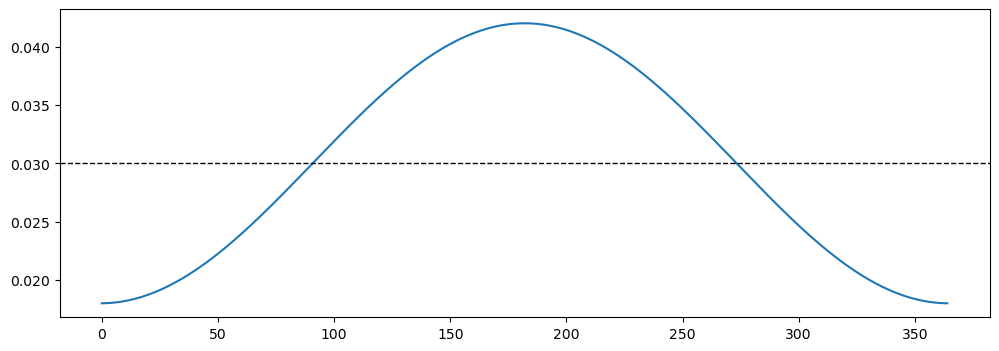

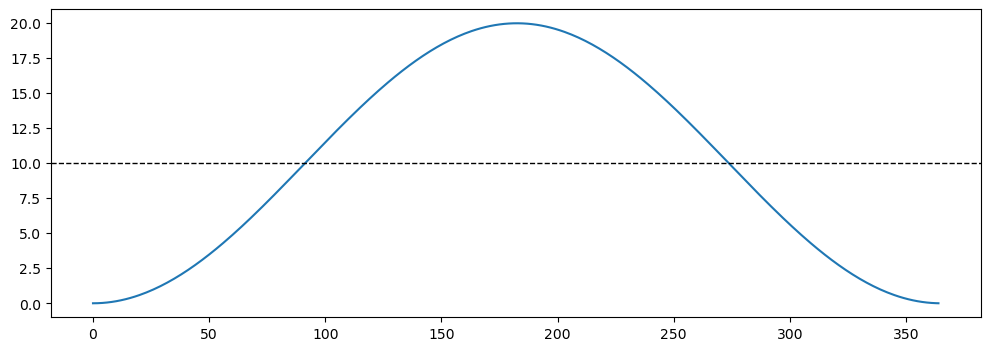

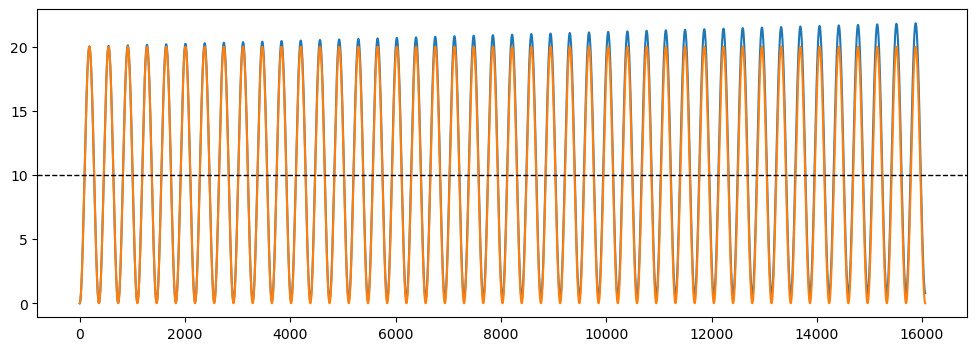

In [2]:
tends_per_day = 8
days_per_year = 365
years_amount = 44

def seasonal_cycle(day):
    return -10*np.cos(2*np.pi*day / days_per_year) + 10

def warming_rate(day, base=0.03, amp=0.012, peak_day=182):
    seasonal_modulation = np.cos(2*np.pi*(day - peak_day) / days_per_year)
    return base + amp*seasonal_modulation

n_days = days_per_year*years_amount

time_days = np.arange(n_days)
time_years = time_days / days_per_year
day_of_year = time_days % days_per_year

S = seasonal_cycle(day_of_year)
a = warming_rate(day_of_year)

T = S + a*time_years

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(a[0:365])
ax.axhline(0.03, color='black', lw=1.0, ls='--')
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(S[0:365])
ax.axhline(10, color='black', lw=1.0, ls='--')
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(T)
ax.plot(S)
ax.axhline(10, color='black', lw=1.0, ls='--')
plt.show()

In [3]:
day_of_year

array([  0,   1,   2, ..., 362, 363, 364], shape=(16060,))

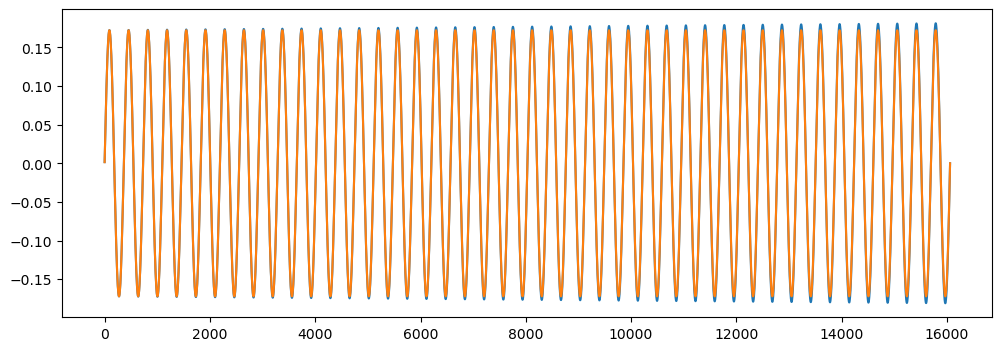

In [4]:
def forward_tendency_same_length(x):
    out = np.zeros_like(x, dtype=float)
    out[:-1] = x[1:] - x[:-1]
    return out

DT = forward_tendency_same_length(T)
DS = forward_tendency_same_length(S)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(DT)
ax.plot(DS)
plt.show()

In [5]:
year_labels = np.arange(years_amount)
days = np.arange(days_per_year)

T_y_d = T.reshape(years_amount, days_per_year)
S_y_d = S.reshape(years_amount, days_per_year)

DT_y_d = DT.reshape(years_amount, days_per_year)
DS_y_d = DS.reshape(years_amount, days_per_year)

In [6]:
half = years_amount // 2

periods = {
    'Ptrend':  [year_labels[0], year_labels[-1]],
    'PtrendL': [year_labels[0], year_labels[half - 1]],
    'PtrendR': [year_labels[half], year_labels[-1]],
}

left_years = slice(0, half)
right_years = slice(half, years_amount)

clim_temp = {
    'PtrendL': T_y_d[left_years].mean(axis=0),
    'PtrendR': T_y_d[right_years].mean(axis=0),
}

clim_tend = {
    'PtrendL': DT_y_d[left_years].mean(axis=0),
    'PtrendR': DT_y_d[right_years].mean(axis=0),
}

clim_temp_ref = {
    'PtrendL': S_y_d[left_years].mean(axis=0),
    'PtrendR': S_y_d[right_years].mean(axis=0),
}

clim_tend_ref = {
    'temp': DS_y_d[left_years].mean(axis=0),
    'tend': DS_y_d[right_years].mean(axis=0),
}

delta_T = clim_temp['PtrendR'] - clim_temp['PtrendL']
delta_D = clim_tend['PtrendR'] - clim_tend['PtrendL']

mu = delta_T.mean()
tau = mu / half

Theta = delta_T - mu
theta = Theta / half

sum kappa = 22.0
half period length = 22.0
max yearly C closure = 7.105427357601002e-15
tau from climatologies = 0.030000000000000002
tau from weighted C    = 0.029999999999997584
tau reference sum      = 0.0
tau relative sum       = 0.029999999999999694


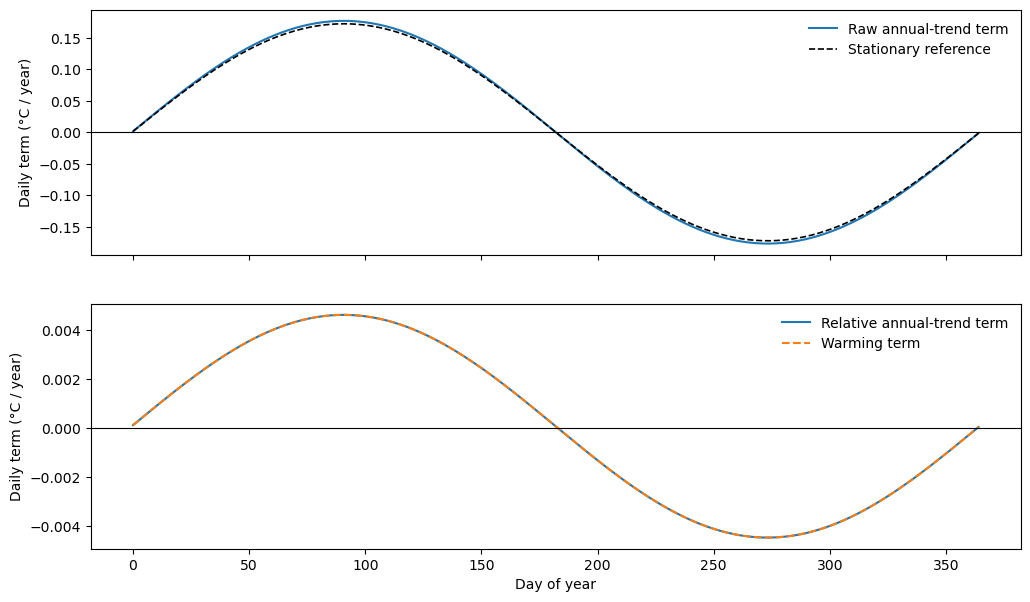

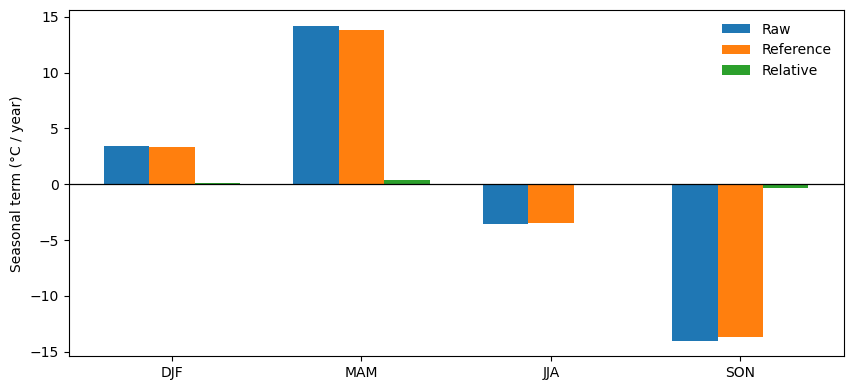

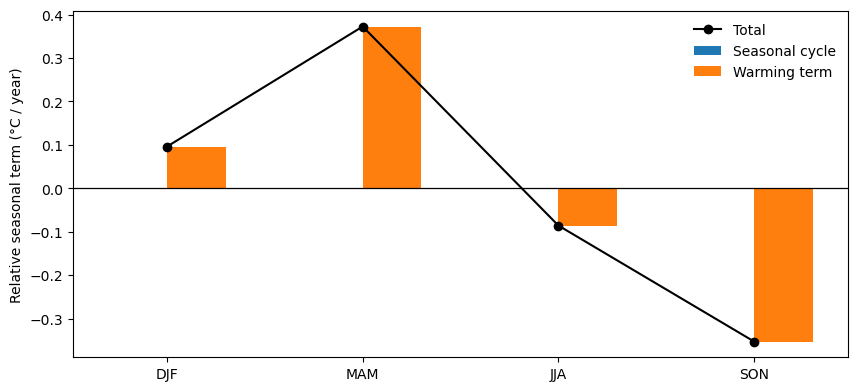

In [7]:
# %%
# Annual-offset style decomposition from daily tendencies

# Make copies for the annual-offset calculation.
# The only correction is the artificial final zero from forward_tendency_same_length.
DT_for_offset = DT_y_d.copy()
DS_for_offset = DS_y_d.copy()

next_time_day = n_days
next_day = next_time_day % days_per_year
next_time_year = next_time_day / days_per_year

S_next = seasonal_cycle(next_day)
T_next = S_next + warming_rate(next_day)*next_time_year

DT_for_offset[-1, -1] = T_next - T[-1]
DS_for_offset[-1, -1] = S_next - S[-1]

DW_for_offset = DT_for_offset - DS_for_offset

process_tend = {
    'Seasonal cycle': DS_for_offset,
    'Warming term': DW_for_offset,
}

# %%
# Daily contribution to the yearly tendency C(y)

def yearly_daily_contribution(D_y_d):
    alpha = (days + 1.0) / days_per_year
    beta = (days_per_year - 1.0 - days) / days_per_year
    return alpha[None, :]*D_y_d[:-1] + beta[None, :]*D_y_d[1:]


C_day = {
    name: yearly_daily_contribution(D_y_d)
    for name, D_y_d in process_tend.items()
}

C_day['Total'] = sum(C_day.values())

# %%
# Kappa weights for the difference between the two period means

def kappa_weights(years_amount, half):
    y = np.arange(years_amount - 1)
    kappa = np.empty(years_amount - 1, dtype=float)

    kappa[:half] = (np.arange(half) + 1.0) / half
    kappa[half:] = (years_amount - 1.0 - y[half:]) / half

    return kappa


kappa = kappa_weights(years_amount, half)
L = kappa.sum()

print(f'sum kappa = {L:.1f}')
print(f'half period length = {half:.1f}')

# %%
# Annual-offset and annual-trend contributions

mu_day = {
    name: (kappa[:, None]*values).sum(axis=0)
    for name, values in C_day.items()
}

tau_day = {
    name: values / L
    for name, values in mu_day.items()
}

# Stationary reference contribution.
# In the toy model, this is just the seasonal-cycle tendency.
tau_ref_day = {
    'Seasonal cycle': DS_for_offset.mean(axis=0),
    'Warming term': np.zeros(days_per_year),
}

tau_ref_day['Total'] = sum(tau_ref_day.values())

tau_rel_day = {
    name: tau_day[name] - tau_ref_day[name]
    for name in tau_day
}

# %%
# Checks

C_direct = T_y_d[1:].mean(axis=1) - T_y_d[:-1].mean(axis=1)

print('max yearly C closure =', np.max(np.abs(C_day['Total'].sum(axis=1) - C_direct)))
print('tau from climatologies =', tau)
print('tau from weighted C    =', tau_day['Total'].sum())
print('tau reference sum      =', tau_ref_day['Total'].sum())
print('tau relative sum       =', tau_rel_day['Total'].sum())

# %%
# Seasonal grouping

month_lengths = np.array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
month = np.repeat(np.arange(1, 13), month_lengths)

season_of_day = np.empty(days_per_year, dtype='<U3')
season_of_day[np.isin(month, [12, 1, 2])] = 'DJF'
season_of_day[np.isin(month, [3, 4, 5])] = 'MAM'
season_of_day[np.isin(month, [6, 7, 8])] = 'JJA'
season_of_day[np.isin(month, [9, 10, 11])] = 'SON'

season_order = ['DJF', 'MAM', 'JJA', 'SON']

def seasonal_sum(day_values):
    return np.array([
        day_values[season_of_day == season].sum()
        for season in season_order
    ])


tau_season = {
    name: seasonal_sum(values)
    for name, values in tau_day.items()
}

tau_ref_season = {
    name: seasonal_sum(values)
    for name, values in tau_ref_day.items()
}

tau_rel_season = {
    name: seasonal_sum(values)
    for name, values in tau_rel_day.items()
}

# %%
# Plot daily annual-trend terms

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(days, tau_day['Total'], label='Raw annual-trend term')
axes[0].plot(days, tau_ref_day['Total'], color='black', lw=1.2, ls='--', label='Stationary reference')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_ylabel('Daily term (°C / year)')
axes[0].legend(frameon=False)

axes[1].plot(days, tau_rel_day['Total'], label='Relative annual-trend term')
axes[1].plot(days, tau_rel_day['Warming term'], ls='--', label='Warming term')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_ylabel('Daily term (°C / year)')
axes[1].set_xlabel('Day of year')
axes[1].legend(frameon=False)

plt.show()

# %%
# Plot seasonal annual-trend terms before and after reference subtraction

x = np.arange(len(season_order))
width = 0.24

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.bar(x - width, tau_season['Total'], width=width, label='Raw')
ax.bar(x, tau_ref_season['Total'], width=width, label='Reference')
ax.bar(x + width, tau_rel_season['Total'], width=width, label='Relative')

ax.axhline(0, color='black', lw=0.9)
ax.set_xticks(x)
ax.set_xticklabels(season_order)
ax.set_ylabel('Seasonal term (°C / year)')
ax.legend(frameon=False)

plt.show()

# %%
# Plot process split of the relative annual-trend contribution

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.bar(x - 0.15, tau_rel_season['Seasonal cycle'], width=0.30, label='Seasonal cycle')
ax.bar(x + 0.15, tau_rel_season['Warming term'], width=0.30, label='Warming term')

ax.plot(x, tau_rel_season['Total'], color='black', marker='o', lw=1.5, label='Total')

ax.axhline(0, color='black', lw=0.9)
ax.set_xticks(x)
ax.set_xticklabels(season_order)
ax.set_ylabel('Relative seasonal term (°C / year)')
ax.legend(frameon=False)

plt.show()